# E12 Matrix Factorization Scale-Imbalance Preconditioning

### Problem

This notebook tests whether spectral orthogonalization acts as a preconditioner in ten-factor matrix factorization. The represented model is

$$\widehat X=W_1W_2\cdots W_{10},\qquad g(W_{1:10})=\frac{1}{2d^2}\lVert W_1W_2\cdots W_{10}-X^\star\rVert_F^2.$$

The first and last factors are initialized with explicit scales while the middle factors start at identity, so severe endpoint scale imbalance creates a natural hard regime. The hypothesis is that exact or low-order polar Muon variants can improve recovery under this imbalance, especially as target condition number increases.


### Metric And Function Definitions

The plots and tables use these diagnostics. They are defined here so symbols like `srank()` are not left implicit.

Let the singular values of a matrix $M$ be $\sigma_1\ge\sigma_2\ge\cdots\ge0$.

| name in notebook/code | definition | how to read it |
|---|---|---|
| `srank(M)` / `stable_rank(M)` | $\operatorname{srank}(M)=\lVert M\rVert_F^2/(\lVert M\rVert_{op}^2+\epsilon)=\sum_i\sigma_i^2/(\sigma_1^2+\epsilon)$ | Soft dimension based on energy; high means energy is spread over many singular directions. |
| `effective_rank(M)` | $\exp\{-\sum_i p_i\log p_i\}$, where $p_i=\sigma_i/(\sum_j\sigma_j+\epsilon)$ | Entropy rank; high means singular mass is evenly spread. |
| `nuclear_fro_ratio(M)` | $\lVert M\rVert_*^2/(\lVert M\rVert_F^2+\epsilon)=(\sum_i\sigma_i)^2/(\sum_i\sigma_i^2+\epsilon)$ | Another spectral-spread score; larger means less concentrated spectrum. |
| `condition_score` | mean `nuclear_fro_ratio(gradient)` divided by mean `stable_rank(activation/factor)` | Larger is the paper-style regime where spectral updates are predicted to help more. |
| `top_sv_error` | $\lVert \sigma_{1:k}(\widehat X)-\sigma_{1:k}(X^\star)\rVert_2/(\lVert\sigma_{1:k}(X^\star)\rVert_2+\epsilon)$ | Lower means leading singular values are recovered better. |
| `descent_alignment` / `grad_update_cosine` | $\langle -G,\Delta\rangle/(\lVert G\rVert_F\lVert\Delta\rVert_F+\epsilon)$ | Near 1 follows negative gradient; near 0 is orthogonal; negative is locally uphill. |
| `relative_step_size` | $\lVert\Delta\theta\rVert_F/(\lVert\theta\rVert_F+\epsilon)$, aggregated across parameter blocks | Size of the update relative to current parameter scale. |
| `balancedness(W_{1:K})` | average adjacent Gram mismatch $\lVert W_i^\top W_i-W_{i+1}W_{i+1}^\top\rVert_F/(\lVert W_i^\top W_i\rVert_F+\lVert W_{i+1}W_{i+1}^\top\rVert_F+\epsilon)$ | Lower means neighboring factors have more compatible scale/geometry. |
| `log_error_gap_vs_adam` / heatmap gap | $\log_{10}e_{method}-\log_{10}e_{Adam}$ | Negative favors the method; positive favors Adam. |


## Implementation Details: Skip Unless Modifying The Experiment

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Runs

In [ ]:
NOTEBOOK_ID = "E12 MF scale-imbalance preconditioning"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon-Exact", "Muon-NS-1", "Muon", "NormalizedSGD", "SpectralNormSGD", "Adam", "SGD", "Shampoo"]
SEEDS = list(range(5))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 1200

BASE_SPEC = dict(problem="MatrixFactorization", d=60, rank=5, factor_rank=5, num_factors=10, lr=0.01,
                 iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
                 diagnostic_every=1 if SMOKE_TEST else 20,
                 early_stop=True, early_stop_min_steps=100, early_stop_patience=20, early_stop_min_delta=1e-8,
                 device_type=DEVICE.type, dtype_name=DTYPE_NAME)
SPECTRUM_CASES = [
    dict(spectrum_case="hard-k1", spectrum="hard-cutoff", kappa=1.0),
    dict(spectrum_case="exp-k10", spectrum="exponential-decay", kappa=10.0),
    dict(spectrum_case="exp-k100", spectrum="exponential-decay", kappa=100.0),
]
SCALES = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([{**BASE_SPEC, **case, "left_scale": ls, "right_scale": rs, "algo": algo, "seed": seed}
                     for case in SPECTRUM_CASES for ls in SCALES for rs in SCALES for algo in ALGOS for seed in SEEDS])
runs.insert(0, "run_id", range(len(runs)))
print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


### Pseudocode

```text
for each spectrum condition, endpoint scale pair, optimizer, seed:
    construct target matrix using MatrixFactorization problem
    initialise ten factors with requested first/last scales
    train using repo optimizer factory
    record recovery error, chain balancedness, singular-value recovery, and stop reason
```


### Worker Definition

In [ ]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def randn(shape, seed, device, dtype):
    shape = tuple(int(dim) for dim in shape)
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


def make_optimizer(algo, params, lr, rank=None):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-Exact":
        return optimizers.MuonExact(params, lr=lr, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-5":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, variant="randsvd", rank=rank)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="spectral", momentum=0.0)
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr)
    raise ValueError(f"unknown optimizer: {algo}")


def nuclear_fro_ratio(matrix, epsilon=1e-12):
    singular_values = torch.linalg.svdvals(matrix.detach())
    numerator = singular_values.sum().square()
    denominator = singular_values.square().sum().clamp_min(epsilon)
    return float((numerator / denominator).detach().cpu())


def relative_update_diagnostics(params_before, params_after, gradients):
    updates = [after.detach() - before.detach() for before, after in zip(params_before, params_after)]
    return {
        "descent_alignment": util.diagnostics.descent_alignment(gradients, updates),
        "relative_step_size": util.diagnostics.relative_step_size(params_before, updates),
        **util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update"),
        **util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad"),
    }


def summarize_last_rows(runs, group_columns):
    ordered = runs.sort_values(["run_id", "step"])
    return ordered.groupby(group_columns, as_index=False, observed=True).tail(1).reset_index(drop=True)

def single_run(run):
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)
    device = torch.device(run["device_type"])
    problem = problems.MatrixFactorization.make_matrix_factorization_problem(
        run["d"], run["rank"], spectrum=run["spectrum"], kappa=run["kappa"], seed=run["seed"],
        device=device, dtype=dtype, factor_rank=run["factor_rank"], num_factors=int(run.get("num_factors", 10)))
    factor_inits = problems.MatrixFactorization.initialize_factor_chain(
        int(run["d"]), int(run["factor_rank"]), seed=int(run["seed"]) + 10, device=device, dtype=dtype,
        num_factors=int(run.get("num_factors", 10)),
        left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
    )
    factors = [factor.requires_grad_(True) for factor in factor_inits]
    params = factors
    opt = make_optimizer(run["algo"], params, run["lr"], rank=run["rank"])
    initial_loss = float(problem.loss(*factors).detach().cpu())
    best_loss = initial_loss
    wait = 0
    rows = []
    start = time.perf_counter()
    stop_reason = "max_steps"
    for step in range(int(run["iters"]) + 1):
        do_diag = (step == 0) or (step == run["iters"]) or (step % int(run["diagnostic_every"]) == 0)
        if do_diag:
            loss_value = float(problem.loss(*factors).detach().cpu())
            estimate = problem.estimate(*factors)
            recovery = util.diagnostics.relative_matrix_error(estimate, problem.target)
            rows.append({**run, "step": step, "initial_loss": initial_loss, "loss": loss_value,
                         "best_loss": best_loss, "recovery_error": recovery,
                         "balancedness": util.diagnostics.balancedness(*factors),
                         "top_sv_error": util.diagnostics.top_singular_value_error(estimate, problem.target, k=run["rank"]),
                         "elapsed_s": time.perf_counter() - start, "stop_reason": stop_reason})
        if step == run["iters"]:
            break
        loss = problem.loss(*factors)
        loss.backward()
        opt.step()
        for p in params:
            p.grad = None
        current = float(problem.loss(*factors).detach().cpu())
        if best_loss - current > run["early_stop_min_delta"]:
            best_loss = current
            wait = 0
        else:
            wait += 1
        if run["early_stop"] and step >= run["early_stop_min_steps"] and wait >= run["early_stop_patience"]:
            stop_reason = "early_stop"
            break
    return pd.DataFrame(rows)


## Results

In [4]:
runs = util.run_experiments(runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND,
                            algo_order=ALGOS, sort_columns=("run_id", "step"), desc=NOTEBOOK_ID)
IPython.display.display(runs)


E12 MF scale-imbalance preconditioning:   0%|          | 0/3000 [00:00<?, ?run/s]

E12 MF scale-imbalance preconditioning:   0%|          | 1/3000 [00:03<2:31:41,  3.03s/run]

E12 MF scale-imbalance preconditioning:   4%|▎         | 109/3000 [00:04<01:24, 34.39run/s]

E12 MF scale-imbalance preconditioning:   6%|▌         | 173/3000 [00:05<01:05, 43.27run/s]

E12 MF scale-imbalance preconditioning:   8%|▊         | 249/3000 [00:06<00:52, 52.88run/s]

...

E12 MF scale-imbalance preconditioning:  98%|█████████▊| 2931/3000 [01:17<00:02, 24.47run/s]

E12 MF scale-imbalance preconditioning:  99%|█████████▊| 2956/3000 [01:18<00:01, 24.05run/s]

E12 MF scale-imbalance preconditioning:  99%|█████████▉| 2981/3000 [01:19<00:00, 22.96run/s]

E12 MF scale-imbalance preconditioning: 100%|██████████| 3000/3000 [01:20<00:00, 37.23run/s]

,run_id,problem,d,rank,factor_rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,...,seed,step,initial_loss,loss,best_loss,recovery_error,balancedness,top_sv_error,elapsed_s,stop_reason
0,0,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,0,0,0.000694,0.000694,0.000694,1.000000,0.236804,0.999999,0.002220,max_steps
1,0,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,0,20,0.000694,0.000190,0.000141,0.523153,0.000249,0.523123,0.042825,max_steps
2,0,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,0,40,0.000694,0.000148,0.000141,0.461882,0.000334,0.461816,0.046157,max_steps
3,0,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,0,60,0.000694,0.000143,0.000140,0.453201,0.001097,0.453150,0.051455,max_steps
4,0,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,0,80,0.000694,0.000139,0.000139,0.447819,0.003784,0.447618,0.057896,max_steps
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69624,2999,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,4,1120,2.927616,0.000041,0.000041,0.397758,0.718820,0.269593,0.809709,max_steps
69625,2999,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,4,1140,2.927616,0.000041,0.000041,0.393397,0.718740,0.267092,0.827065,max_steps
69626,2999,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,4,1160,2.927616,0.000040,0.000040,0.389569,0.718674,0.263706,0.839831,max_steps
69627,2999,MatrixFactorization,60,5,5,0.01,1200,20,True,100,...,4,1180,2.927616,0.000039,0.000039,0.386034,0.718617,0.259593,0.850947,max_steps


### Individual Loss Curves

**What this plot is:** raw training-loss trajectories for the endpoint scale-imbalance experiment.

- **One line:** one full run, meaning one `(spectrum condition, left_scale, right_scale, optimizer, seed)` combination.
- **Panel:** target spectrum/condition-number case.
- **Color:** optimizer identity.
- **X-axis:** optimizer step.
- **Y-axis:** training loss on a log scale; lower is better.
- **How to read it:** compare color bands within a panel. If one color drops earlier and stays lower, that optimizer is handling the scale-imbalance regime better. If a color has many high flat lines, it is plateauing in some scale cells.


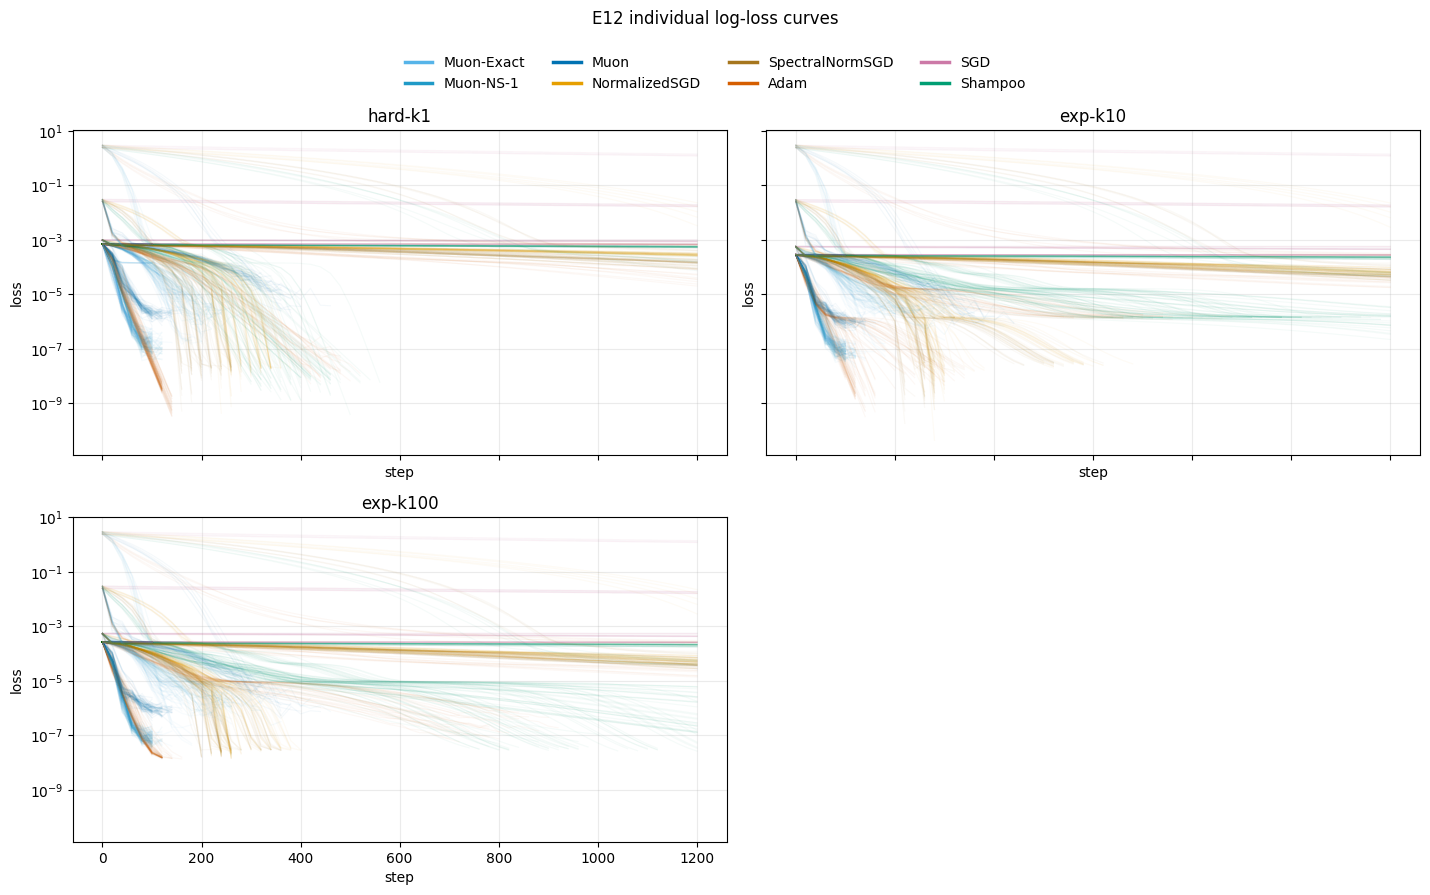

In [5]:
import plotting
from matplotlib.lines import Line2D


def plot_individual_loss_curves(frame, panel_column, *, panel_order=None, title_prefix="Individual loss curves"):
    plot_frame = frame[np.isfinite(frame["loss"])].copy()
    if plot_frame.empty:
        print("No finite loss values to plot.")
        return None, None
    plot_frame["loss_plot"] = plot_frame["loss"].clip(lower=1e-300)
    panels = list(panel_order) if panel_order is not None else sorted(plot_frame[panel_column].dropna().unique())
    ncols = min(2, max(1, len(panels)))
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.2 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    for ax, panel in zip(axes_flat, panels):
        sub = plot_frame[plot_frame[panel_column] == panel].sort_values(["run_id", "step"])
        run_count = max(1, sub["run_id"].nunique())
        alpha = max(0.04, min(0.30, 18.0 / run_count))
        for _, group in sub.groupby("run_id", observed=True, sort=False):
            algo = str(group["algo"].iloc[0])
            ax.plot(
                group["step"],
                group["loss_plot"],
                color=plotting.algorithm_color(algo),
                linewidth=0.85,
                alpha=alpha,
            )
        ax.set_title(str(panel))
        ax.set_xlabel("step")
        ax.set_ylabel("loss")
        ax.set_yscale("log")
        ax.grid(alpha=0.25)
    for ax in axes_flat[len(panels):]:
        ax.axis("off")
    algos = [algo for algo in ALGOS if algo in set(plot_frame["algo"].astype(str))]
    handles = [Line2D([0], [0], color=plotting.algorithm_color(algo), linewidth=2.5, label=algo) for algo in algos]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(title_prefix, y=1.06 if handles else 1.02)
    fig.tight_layout()
    return fig, axes

fig, axes = plot_individual_loss_curves(runs, "spectrum_case", panel_order=[case["spectrum_case"] for case in SPECTRUM_CASES], title_prefix="E12 individual log-loss curves")
plt.show()


### Result Tables

**What this table is:** the final-run summary for each scale cell and optimizer.

- **Rows:** one `(spectrum_case, left_scale, right_scale, optimizer)` group.
- **median_recovery:** lower is better; this is the main success metric.
- **median_balancedness:** lower means adjacent factors have more compatible Gram geometry.
- **median_top_sv_error:** lower means the leading target singular values are recovered better.
- **median_steps / stop_reason:** tells whether the run ended by the budget or early stopping.
- **How to read it:** do not rank methods by loss alone; use recovery first, then balancedness/top-singular-value error as diagnostics.


In [6]:
run_summary = summarize_last_rows(runs, ["run_id"])
summary = run_summary.groupby(["spectrum_case", "left_scale", "right_scale", "algo"], as_index=False, observed=True).agg(
    median_recovery=("recovery_error", "median"), median_balancedness=("balancedness", "median"), median_top_sv_error=("top_sv_error", "median"),
    median_steps=("step", "median"), stop_reason=("stop_reason", lambda x: x.mode().iloc[0] if len(x.mode()) else "")
)
IPython.display.display(summary.sort_values(["spectrum_case", "left_scale", "right_scale", "median_recovery"]))


,spectrum_case,left_scale,right_scale,algo,median_recovery,median_balancedness,median_top_sv_error,median_steps,stop_reason
4,exp-k10,0.0001,0.0001,NormalizedSGD,0.003341,0.000107,0.003341,300.0,max_steps
0,exp-k10,0.0001,0.0001,Adam,0.004890,0.142910,0.000755,120.0,max_steps
7,exp-k10,0.0001,0.0001,SpectralNormSGD,0.006189,0.000286,0.006147,280.0,max_steps
2,exp-k10,0.0001,0.0001,Muon-Exact,0.016510,0.545923,0.009191,120.0,max_steps
3,exp-k10,0.0001,0.0001,Muon-NS-1,0.016961,0.056937,0.010679,100.0,max_steps
...,...,...,...,...,...,...,...,...,...
598,hard-k1,1.0000,1.0000,Shampoo,0.469004,0.701355,0.245299,1200.0,max_steps
599,hard-k1,1.0000,1.0000,SpectralNormSGD,0.765522,0.715803,0.544125,1200.0,max_steps
592,hard-k1,1.0000,1.0000,Adam,0.967027,0.711764,0.697532,1200.0,max_steps
596,hard-k1,1.0000,1.0000,NormalizedSGD,3.897158,0.692252,2.833962,1200.0,max_steps


### Muon-Exact Vs Adam Gap Heatmaps

**What this plot is:** a winner map over endpoint scale imbalance.

- **One cell:** one pair `(left_scale, right_scale)` for a fixed spectrum case, aggregated over seeds.
- **X-axis:** `right_scale`, the initialization scale of the last factor.
- **Y-axis:** `left_scale`, the initialization scale of the first factor.
- **Color value:** `log10(error_MuonExact) - log10(error_Adam)`.
- **Good direction for Muon-Exact:** negative values. Positive values mean Adam has lower recovery error.
- **Decision rule:** the preconditioning story is stronger if negative cells concentrate in imbalanced or ill-conditioned regimes, not only in easy balanced cells.


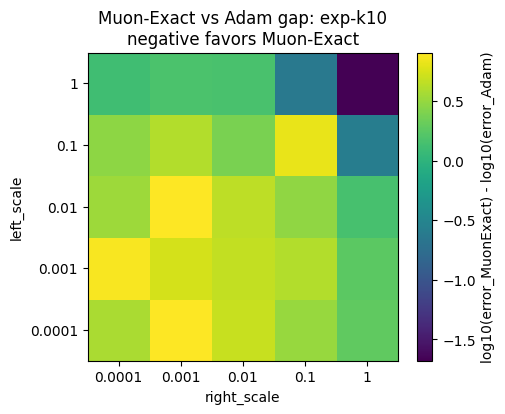

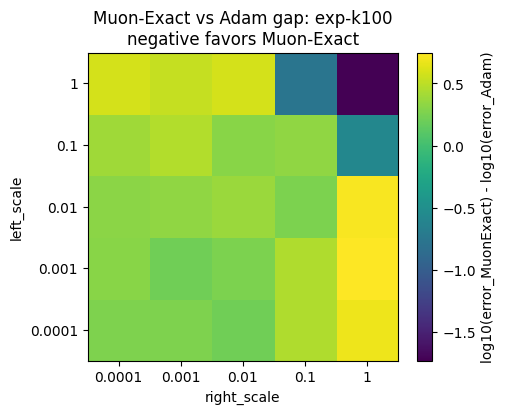

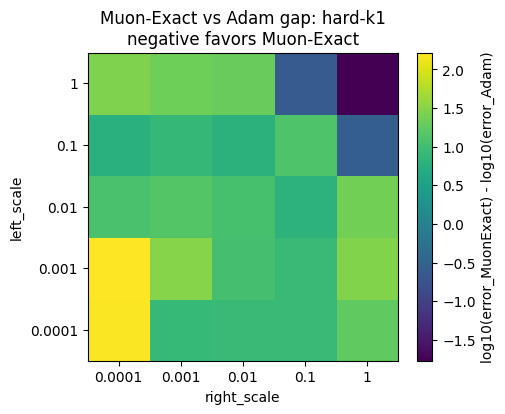

In [7]:
for spectrum_case in sorted(run_summary["spectrum_case"].unique()):
    table = run_summary[run_summary["spectrum_case"] == spectrum_case]
    pivot = table.pivot_table(index=["left_scale", "right_scale", "seed"], columns="algo", values="recovery_error", observed=True).reset_index()
    if {"Muon-Exact", "Adam"}.issubset(pivot.columns):
        pivot["gap"] = np.log10(pivot["Muon-Exact"].clip(lower=1e-12)) - np.log10(pivot["Adam"].clip(lower=1e-12))
        heat = pivot.pivot_table(index="left_scale", columns="right_scale", values="gap", aggfunc="median", observed=True)
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(heat.values, origin="lower", aspect="auto")
        ax.set_xticks(range(len(heat.columns)), [f"{x:g}" for x in heat.columns])
        ax.set_yticks(range(len(heat.index)), [f"{y:g}" for y in heat.index])
        ax.set_xlabel("right_scale")
        ax.set_ylabel("left_scale")
        ax.set_title(f"Muon-Exact vs Adam gap: {spectrum_case}\nnegative favors Muon-Exact")
        plt.colorbar(im, ax=ax, label="log10(error_MuonExact) - log10(error_Adam)")
        plt.show()


### Condition Number Scaling

**What this plot is:** sensitivity to target condition number after aggregating over the scale grid.

- **One line:** one optimizer.
- **X-axis:** target condition number `kappa` on a log scale.
- **Y-axis:** median recovery error on a log scale; lower is better.
- **How to read it:** a robust preconditioner should have a lower curve and a flatter slope as `kappa` increases. A steep upward curve means the method degrades quickly on ill-conditioned targets.


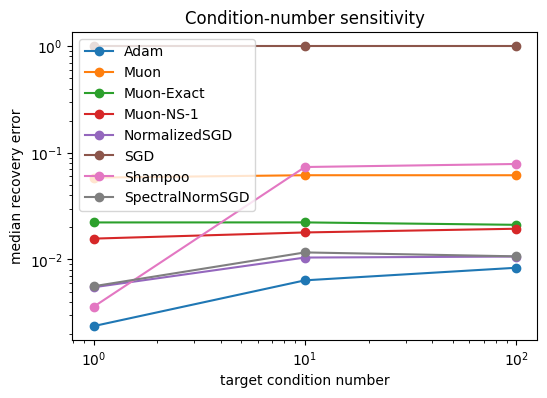

In [8]:
condition_summary = run_summary.groupby(["kappa", "algo"], as_index=False, observed=True).agg(median_recovery=("recovery_error", "median"))
fig, ax = plt.subplots(figsize=(6, 4))
for algo, group in condition_summary.groupby("algo", observed=True):
    ax.plot(group["kappa"], group["median_recovery"], marker="o", label=algo)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("target condition number")
ax.set_ylabel("median recovery error")
ax.set_title("Condition-number sensitivity")
ax.legend()
plt.show()


### Reading The Result

Read E12 in this order: loss curves for optimization behavior, result tables for numerical winners, gap heatmaps for where Muon-Exact beats Adam, and condition-number scaling for whether that advantage survives harder spectra.

This experiment supports the preconditioning story if Muon-Exact or Muon-NS-1 has negative gaps against Adam in imbalanced and ill-conditioned regimes, and if its recovery error grows more slowly with target condition number.


### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| Spectral orthogonalization can act as a preconditioner under endpoint scale imbalance. | Muon-Exact-vs-Adam gap heatmaps and condition-number scaling curves isolate imbalanced and ill-conditioned cases. | Partial | Benefits are regime-dependent and normalization baselines can be competitive. |
| Preconditioning should be evaluated jointly with factor geometry. | The summary table reports recovery, chain balancedness, top-singular-value error, steps, and stop reason. | Yes | Fixed learning rates and endpoint-only scale sweeps limit how broadly the conclusion transfers. |
